<a href="https://colab.research.google.com/github/SlepenkovaDaria/My-homework/blob/main/%D0%9F%D0%BE%D1%80%D1%82%D1%84%D0%B5%D0%BB%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_13431/937745312.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = "2024-01-01", end = "2025-01-01")["Close"]
[*********************100%***********************]  5 of 5 completed



Доли ценных бумаг в эффективном портфеле с ожидаемой доходностью портфеля M = 0.001
AAPL: 0.417113
MSFT: 0.113802
TSLA: 0.476990
GOOGL: 0.008929
NVDA: -0.016834
Сумма весов = 1.000000
Ожидаемая доходность = 0.001000
Дисперсия = 0.000128
Стандартное отклонение = 0.011307


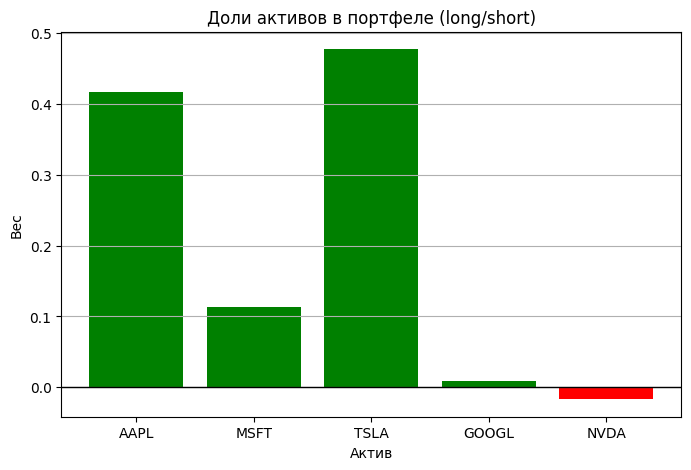

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "TSLA", "GOOGL", "NVDA"]
data = yf.download(tickers, start = "2024-01-01", end = "2025-01-01")["Close"]
data = data.dropna()
profit = data.pct_change().dropna()

E = profit.mean().values
C = profit.cov().values
C_inv = np.linalg.inv(C)
n = len(tickers)
one = np.ones(n)

alpha = E @ C_inv @ E
betta = one @ C_inv @ E
gamma = one @ C_inv @ one
delta = alpha * gamma - betta * betta

M = 0.001

v1 = - (gamma / delta) * E + (betta / delta) * one
v2 = (betta /delta) * E - (alpha / delta) * one
x_opt = - M * (C_inv @ v1) - (C_inv @ v2)

print(f"\nДоли ценных бумаг в эффективном портфеле с ожидаемой доходностью портфеля M = {M}")
for ticker, w in zip(tickers, x_opt):
    print(f"{ticker}: {w:.6f}")

print(f"Сумма весов = {x_opt.sum():.6f}")
print(f"Ожидаемая доходность = {x_opt @ E:.6f}")
print(f"Дисперсия = {x_opt.T @ C @ x_opt:.6f}")
print(f"Стандартное отклонение = {np.sqrt(x_opt.T @ C @ x_opt):.6f}")

plt.figure(figsize = (8,5))
colors = ["green" if w > 0 else "red" for w in x_opt]

plt.bar(tickers, x_opt, color = colors)
plt.axhline(0, color = "black", linewidth = 1)
plt.title("Доли активов в портфеле (long/short)")
plt.ylabel("Вес")
plt.xlabel("Актив")
plt.grid(axis = "y")
plt.show()


/tmp/ipykernel_13431/2650952413.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = "2024-01-01", end = "2025-01-01")["Close"]
[*********************100%***********************]  5 of 5 completed



Доли ценных бумаг в эффективном портфеле
AAPL: 0.389458
MSFT: 0.086382
TSLA: 0.588382
GOOGL: -0.038441
NVDA: -0.025781
Сумма весов = 1.000000
Ожидаемая доходность = 0.000750
Дисперсия = 0.000125
Стандартное отклонение = 0.011188


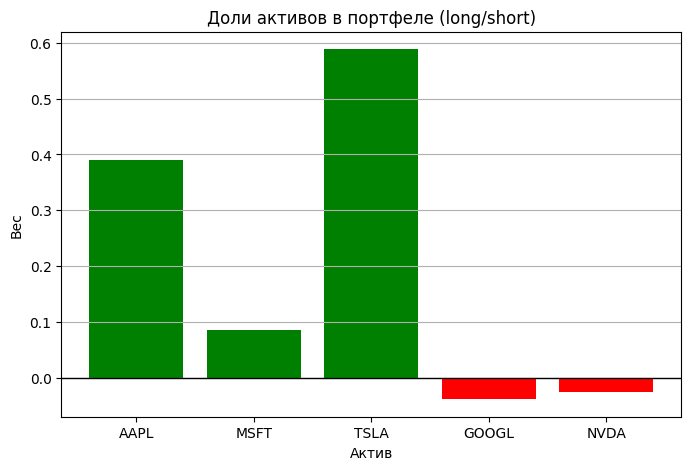

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "TSLA", "GOOGL", "NVDA"]
data = yf.download(tickers, start = "2024-01-01", end = "2025-01-01")["Close"]
data = data.dropna()
profit = data.pct_change().dropna()

E = profit.mean().values
C = profit.cov().values
C_inv = np.linalg.inv(C)
n = len(tickers)
one = np.ones(n)

x_opt = (C_inv @ one) / (one @ C_inv @ one)

print(f"\nДоли ценных бумаг в эффективном портфеле")
for ticker, w in zip(tickers, x_opt):
    print(f"{ticker}: {w:.6f}")

print(f"Сумма весов = {x_opt.sum():.6f}")
print(f"Ожидаемая доходность = {x_opt @ E:.6f}")
print(f"Дисперсия = {x_opt.T @ C @ x_opt:.6f}")
print(f"Стандартное отклонение = {np.sqrt(x_opt.T @ C @ x_opt):.6f}")

plt.figure(figsize = (8,5))
colors = ["green" if w > 0 else "red" for w in x_opt]

plt.bar(tickers, x_opt, color = colors)
plt.axhline(0, color = "black", linewidth = 1)
plt.title("Доли активов в портфеле (long/short)")
plt.ylabel("Вес")
plt.xlabel("Актив")
plt.grid(axis = "y")
plt.show()


Были рассмтрены акции пяти компаний: Apple Inc., Microsoft, Tesla, Google, Nvidia в период c 01.01.2024 по 01.01.2025, определены доли инвестируемого капитала. Заметим, что $$\sigma_1 > \sigma_2, M_1 < M_2$$
так как во втором случае мы составляли эффективный портфель, а в первом - портфель с заданной ожидаемой доходностью.